# Data-Driven Stock Analysis using Time Series Models

## Objective

This project develops a quantitative stock-analysis and portfolio-construction framework using classical time-series methods on NSE-listed equities.

The workflow includes:

1. Stock universe selection
2. Data preprocessing and stationarity analysis
3. ARIMA and Prophet forecasting
4. Volatility and trend analysis
5. Forecast-driven portfolio construction
6. Walk-forward model evaluation
7. Forward deployment analysis using StockGro simulation

The project emphasises:
- statistical rigor
- realistic validation
- volatility-aware allocation
- and empirical interpretation of forecasting behaviour


## Imports and Configuration and Metrics

This section imports all required libraries and defines:
- Selected NSE equities
- Date ranges
- Forecast horizon
- Portfolio capital


In [117]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from itertools import product
from pathlib import Path
import yfinance as yf
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.seasonal import STL
from sklearn.metrics import mean_squared_error



OUT = Path("outputs")
OUT.mkdir(exist_ok=True)

In [118]:
STOCKS = {
    "RELIANCE.NS":  "Energy",
    "HDFCBANK.NS":  "Banking",
    "TATASTEEL.NS": "Metals",
    "APOLLOHOSP.NS":"Healthcare",
    "MARUTI.NS":    "Auto",
}
TICKERS       = list(STOCKS.keys())
START         = "2020-01-01"
END           = "2026-05-13"
TRAIN_END     = "2025-06-30"
TEST_START    = "2025-07-01"
CAPITAL       = 1_000_000
FORECAST_DAYS = 5

In [119]:
# metrics

def mape(actual, pred):
    a, p = np.array(actual), np.array(pred)
    return np.mean(np.abs((a - p) / a)) * 100


def rmse(actual, pred):
    return np.sqrt(mean_squared_error(actual, pred))


def dir_acc(actual, pred, prev):
    actual = np.array(actual)
    pred = np.array(pred)
    prev = np.array(prev)

    actual_dir = np.sign(actual - prev)
    pred_dir = np.sign(pred - prev)

    # treat flat movement as upward persistence
    actual_dir[actual_dir == 0] = 1
    pred_dir[pred_dir == 0] = 1

    return (
            np.mean(actual_dir == pred_dir)
            * 100
    )


## Notebook Workflow

The notebook follows a sequential quantitative workflow:

- Task 1 → Stock selection and diversification
- Task 2 → Cleaning, stationarity testing, and returns
- Task 3 → Forecasting using ARIMA, Prophet, and ensembles
- Task 4 → Volatility and STL trend analysis
- Task 5 → Portfolio allocation
- Task 6 → Forecast evaluation and diagnostics
- Optional → Figures


## Task 1 — Stock Universe Selection

Stocks were selected across diversified sectors to reduce concentration risk.
Rolling annualised volatility was used to compare stability and risk profiles.


In [120]:
raw   = yf.download(TICKERS, start=START, end=END, interval="1d", auto_adjust=True,progress=False)
close = raw["Close"].dropna(how="all")

rolling_vol = close.pct_change().rolling(30).std() * np.sqrt(252)
mean_vol    = rolling_vol.mean()

print(f"\n{'Stock':<16} {'Sector':<10} {'Avg Ann.Vol':>11}")
for t, s in STOCKS.items():
    print(f"{t:<16} {s:<10} {mean_vol[t]:>10.2%}")


Stock            Sector     Avg Ann.Vol
RELIANCE.NS      Energy         25.12%
HDFCBANK.NS      Banking        23.02%
TATASTEEL.NS     Metals         33.62%
APOLLOHOSP.NS    Healthcare     28.85%
MARUTI.NS        Auto           25.42%



## Task 2 — Data Preprocessing

This section:
- Cleans missing values
- Resamples data to business-day frequency
- Computes log returns
- Performs ADF stationarity testing


In [121]:
close = close.asfreq("B")
close = close.ffill().bfill()

def adf_test(series, name):
    r    = adfuller(series.dropna())
    pval = r[1]
    tag  = "STATIONARY" if pval < 0.05 else "NON-STATIONARY"
    print(f"  {name:<16} stat={r[0]:7.3f}  p={pval:.4f}  {tag}")
    return pval < 0.05

log_returns = np.log(close / close.shift(1)).dropna()

print("\nADF — price levels:")
for t in TICKERS:
    adf_test(close[t], t)

print("\nADF — log returns:")
for t in TICKERS:
    adf_test(log_returns[t], t)

train = close.loc[:TRAIN_END]
test  = close.loc[TEST_START:]
print(f"\nTrain: {train.index[0].date()} -> {train.index[-1].date()}  ({len(train)} obs)")
print(f"Test : {test.index[0].date()} -> {test.index[-1].date()}   ({len(test)} obs)")


ADF — price levels:
  RELIANCE.NS      stat= -2.031  p=0.2730  NON-STATIONARY
  HDFCBANK.NS      stat= -1.773  p=0.3939  NON-STATIONARY
  TATASTEEL.NS     stat= -0.497  p=0.8926  NON-STATIONARY
  APOLLOHOSP.NS    stat= -0.996  p=0.7548  NON-STATIONARY
  MARUTI.NS        stat= -0.897  p=0.7889  NON-STATIONARY

ADF — log returns:
  RELIANCE.NS      stat=-14.747  p=0.0000  STATIONARY
  HDFCBANK.NS      stat=-17.216  p=0.0000  STATIONARY
  TATASTEEL.NS     stat=-12.389  p=0.0000  STATIONARY
  APOLLOHOSP.NS    stat= -9.676  p=0.0000  STATIONARY
  MARUTI.NS        stat=-10.079  p=0.0000  STATIONARY

Train: 2020-01-01 -> 2025-06-30  (1434 obs)
Test : 2025-07-01 -> 2026-05-12   (226 obs)



## Task 3 — Time Series Forecasting

Forecasting models implemented:
- ARIMA
- Facebook Prophet
- Weighted Ensemble

Walk-forward validation is used to avoid look-ahead bias.


In [122]:
from scipy.stats import jarque_bera
from statsmodels.stats.diagnostic import acorr_ljungbox


# ARIMA ORDER SEARCH

def auto_arima_aic(series, p_range=range(0,3), d=1, q_range=range(0,3)):

    best_aic = np.inf
    best_order = (1,1,1)

    for p, q in product(p_range, q_range):

        try:

            model = ARIMA(
                series,
                order=(p,d,q)
            ).fit(method_kwargs={"maxiter":500})

            # skip unstable fits
            if not model.mle_retvals.get("converged", False):
                continue

            if np.isfinite(model.aic):

                if model.aic < best_aic:
                    best_aic = model.aic
                    best_order = (p,d,q)

        except:
            continue

    return best_order



# ARIMA FORECASTING

arima_results = {}

for ticker in TICKERS:

    print(f"\nARIMA — {ticker}")

    tr = train[ticker].dropna()
    te = test[ticker].dropna()

    # find best order
    order = auto_arima_aic(tr)

    print(f"Best order: {order}")

    # rolling walk-forward validation
    history = list(tr.values)

    test_preds = []

    for obs in te.values:

        model = ARIMA(
            history,
            order=order
        ).fit(method_kwargs={"maxiter": 500})

        pred = model.forecast(steps=1)[0]

        # prevent exploding predictions
        if pred <= 0 or pred > max(history) * 3:
            pred = history[-1]

        test_preds.append(pred)

        history.append(obs)
    # final model on full dataset
    final_model = ARIMA(
        pd.concat([tr, te]),
        order=order
    ).fit(method_kwargs={"maxiter": 500})

    # future forecast
    fc_res = final_model.get_forecast(steps=FORECAST_DAYS)

    forecast_mean = fc_res.predicted_mean.values.tolist()

    conf_int = fc_res.conf_int()

    lower = conf_int.iloc[:, 0].values.tolist()
    upper = conf_int.iloc[:, 1].values.tolist()

    # naive baseline
    prev = [tr.iloc[-1]] + list(te.iloc[:-1])

    naive_preds = prev[:len(te)]

    # metrics
    arima_mape = mape(te.values, test_preds)
    arima_rmse = rmse(te.values, test_preds)
    arima_da = dir_acc(te.values, test_preds, prev[:len(te)])

    naive_mape = mape(te.values, naive_preds)
    naive_rmse = rmse(te.values, naive_preds)
    naive_da = dir_acc(te.values, naive_preds, prev[:len(te)])

    # residual diagnostics
    residuals = final_model.resid.dropna()

    jb_stat, jb_p = jarque_bera(residuals)

    lb = acorr_ljungbox(
        residuals,
        lags=[10],
        return_df=True
    )

    lb_p = lb["lb_pvalue"].iloc[0]

    arima_results[ticker] = {
        "order": order,
        "test_pred": test_preds,
        "forecast": forecast_mean,
        "lower": lower,
        "upper": upper,
        "residuals": residuals,
        "mape": arima_mape,
        "rmse": arima_rmse,
        "dir_acc": arima_da,
        "naive_mape": naive_mape,
        "naive_rmse": naive_rmse,
        "naive_dir_acc": naive_da,
        "jb_pvalue": jb_p,
        "lb_pvalue": lb_p,
    }

    print(f"MAPE     : {arima_mape:.2f}%")
    print(f"RMSE      : {arima_rmse:.2f}")
    print(f"DirAcc    : {arima_da:.1f}%")

    print(f"Naive MAPE: {naive_mape:.2f}%")

    print(f"JB p-val  : {jb_p:.4f}")
    print(f"LjungBox  : {lb_p:.4f}")

    print(f"Forecast  : {[round(v,2) for v in forecast_mean]}")



# PROPHET

prophet_available = False
prophet_results = {}

try:

    from prophet import Prophet
    prophet_available = True

    for ticker in TICKERS:
        print(f"\nProphet — {ticker}")

        tr_df = train[ticker].dropna().reset_index()
        tr_df.columns = ["ds", "y"]

        te_df = test[ticker].dropna().reset_index()
        te_df.columns = ["ds", "y"]

        model = Prophet(
            daily_seasonality=False,
            weekly_seasonality=True,
            yearly_seasonality=True,
            changepoint_prior_scale=0.05
        )

        model.fit(tr_df)

        # direct prediction on test dates
        fc_test = model.predict(te_df[["ds"]])
        test_pred = fc_test["yhat"].values

        # future forecast
        future = model.make_future_dataframe(periods=len(te_df) + FORECAST_DAYS)

        fc = model.predict(future)
        tail = fc.iloc[-FORECAST_DAYS:]
        prev = [tr_df["y"].iloc[-1]] + list(te_df["y"].iloc[:-1])

        prophet_results[ticker] = {
            "test_pred": test_pred.tolist(),
            "forecast": tail["yhat"].tolist(),
            "lower": tail["yhat_lower"].tolist(),
            "upper": tail["yhat_upper"].tolist(),
            "mape": mape(te_df["y"].values, test_pred),
            "rmse": rmse(te_df["y"].values, test_pred),
            "dir_acc": dir_acc(te_df["y"].values,test_pred,prev[:len(te_df)]),}

        print(f"MAPE  : {prophet_results[ticker]['mape']:.2f}%")
        print(f"RMSE  : {prophet_results[ticker]['rmse']:.2f}")


except ImportError:
    print("\nProphet not installed.")


# WEIGHTED ENSEMBLE

ensemble_results = {}
if prophet_available:

    print("\nWeighted Ensemble")

    for ticker in TICKERS:

        ar_tp = np.array(arima_results[ticker]["test_pred"])
        pr_tp = np.array(prophet_results[ticker]["test_pred"])
        ar_fc = np.array(arima_results[ticker]["forecast"])
        pr_fc = np.array(prophet_results[ticker]["forecast"])
        ar_mape = arima_results[ticker]["mape"]
        pr_mape = prophet_results[ticker]["mape"]

        # inverse-error weights
        w_ar = 1 / ar_mape
        w_pr = 1 / pr_mape

        ens_tp = ( w_ar * ar_tp +w_pr * pr_tp) / (w_ar + w_pr)

        ens_fc = (w_ar * ar_fc +w_pr * pr_fc) / (w_ar + w_pr)
        te = test[ticker].dropna()
        prev = [train[ticker].iloc[-1]] + list(te.iloc[:-1])

        ensemble_results[ticker] = {
            "test_pred": ens_tp.tolist(),
            "forecast": ens_fc.tolist(),
            "mape": mape(te.values, ens_tp),
            "rmse": rmse(te.values, ens_tp),
            "dir_acc": dir_acc(te.values,ens_tp,prev[:len(te)]),}

        print(
            f"{ticker:<16} "
            f"MAPE={ensemble_results[ticker]['mape']:.2f}%  "
            f"RMSE={ensemble_results[ticker]['rmse']:.2f}"
        )



# SAVE FORECASTS

forecast_rows = []

for ticker in TICKERS:
    for day in range(FORECAST_DAYS):

        row = {
            "ticker": ticker,
            "day": day + 1,
            "arima_mean": arima_results[ticker]["forecast"][day],
            "arima_lower": arima_results[ticker]["lower"][day],
            "arima_upper": arima_results[ticker]["upper"][day],
        }

        if prophet_available:

            row["prophet_mean"] = prophet_results[ticker]["forecast"][day]
            row["prophet_lower"] = prophet_results[ticker]["lower"][day]
            row["prophet_upper"] = prophet_results[ticker]["upper"][day]

        if ensemble_results:
            row["ensemble_mean"] = ensemble_results[ticker]["forecast"][day]
        forecast_rows.append(row)

forecast_df = pd.DataFrame(forecast_rows)
forecast_df.to_csv(OUT / "forecasts.csv",index=False)

print(f"\nSaved -> {OUT}/forecasts.csv")


ARIMA — RELIANCE.NS
Best order: (2, 1, 2)
MAPE     : 0.88%
RMSE      : 17.67
DirAcc    : 59.3%
Naive MAPE: 0.89%
JB p-val  : 0.0000
LjungBox  : 0.9998
Forecast  : [1361.5, 1362.65, 1363.76, 1361.45, 1362.93]

ARIMA — HDFCBANK.NS
Best order: (2, 1, 2)
MAPE     : 0.81%
RMSE      : 10.23
DirAcc    : 51.8%
Naive MAPE: 0.81%
JB p-val  : 0.0000
LjungBox  : 0.9938
Forecast  : [751.65, 752.85, 752.0, 750.77, 751.32]

ARIMA — TATASTEEL.NS
Best order: (0, 1, 0)
MAPE     : 1.19%
RMSE      : 3.10
DirAcc    : 55.8%
Naive MAPE: 1.19%
JB p-val  : 0.0000
LjungBox  : 0.9335
Forecast  : [212.0, 212.0, 212.0, 212.0, 212.0]

ARIMA — APOLLOHOSP.NS
Best order: (2, 1, 2)
MAPE     : 0.86%
RMSE      : 91.64
DirAcc    : 52.7%
Naive MAPE: 0.86%
JB p-val  : 0.0000
LjungBox  : 0.6363
Forecast  : [8009.31, 7996.32, 8005.16, 8017.03, 8011.57]

ARIMA — MARUTI.NS
Best order: (2, 1, 2)


23:03:14 - cmdstanpy - INFO - Chain [1] start processing


MAPE     : 1.03%
RMSE      : 208.57
DirAcc    : 50.0%
Naive MAPE: 1.02%
JB p-val  : 0.0000
LjungBox  : 0.9998
Forecast  : [13166.6, 13182.2, 13190.69, 13184.57, 13177.57]

Prophet — RELIANCE.NS


23:03:14 - cmdstanpy - INFO - Chain [1] done processing
23:03:14 - cmdstanpy - INFO - Chain [1] start processing


MAPE  : 14.40%
RMSE  : 233.37

Prophet — HDFCBANK.NS


...

MAPE  : 26.81%
RMSE  : 55.34

Prophet — APOLLOHOSP.NS


23:03:15 - cmdstanpy - INFO - Chain [1] done processing
23:03:16 - cmdstanpy - INFO - Chain [1] start processing


MAPE  : 4.14%
RMSE  : 365.31

Prophet — MARUTI.NS


23:03:16 - cmdstanpy - INFO - Chain [1] done processing


MAPE  : 18.39%
RMSE  : 3220.13

Weighted Ensemble
RELIANCE.NS      MAPE=1.18%  RMSE=21.53
HDFCBANK.NS      MAPE=1.16%  RMSE=14.16
TATASTEEL.NS     MAPE=1.68%  RMSE=3.98
APOLLOHOSP.NS    MAPE=1.07%  RMSE=105.70
MARUTI.NS        MAPE=1.45%  RMSE=264.62

Saved -> outputs/forecasts.csv



## Task 4 — Volatility and Trend Analysis

This section analyses:
- Annualised volatility
- Recent rolling volatility
- STL trend decomposition
- Correlation structure


In [123]:
vol_data = {}
for ticker in TICKERS:

    lr = log_returns[ticker].dropna()
    ann_vol = lr.std() * np.sqrt(252)
    recent_vol = (lr.rolling(30).std().iloc[-1]* np.sqrt(252))

    # STL decomposition
    stl = STL(
        close[ticker].dropna(),
        period=252,
        robust=True
    )

    res = stl.fit()
    trend_series = res.trend.dropna()

    # normalize trend
    trend_norm = trend_series / trend_series.iloc[0]

    slope = np.polyfit(
        range(len(trend_norm)),
        trend_norm,
        1
    )[0]

    # trend classification
    if slope > 0.0005:
        trend_dir = "UP"

    elif slope < -0.0005:
        trend_dir = "DOWN"

    else:
        trend_dir = "SIDEWAYS"

    vol_data[ticker] = {
        "ann_vol": ann_vol,
        "recent_vol": recent_vol,
        "trend": trend_dir,
        "slope": slope,
        "stl_res": res,
    }

    print(
        f"{ticker:<16} "
        f"Ann.Vol={ann_vol:.2%}  "
        f"Recent30d={recent_vol:.2%}  "
        f"Trend={trend_dir}"
    )

vol_df = pd.DataFrame({
    t: {
        "ann_vol": vol_data[t]["ann_vol"],
        "recent_vol": vol_data[t]["recent_vol"],
        "trend": vol_data[t]["trend"],
        "slope": vol_data[t]["slope"],
    }
    for t in TICKERS
}).T

vol_df.to_csv(OUT / "volatility_summary.csv")
print(f"Saved -> {OUT}/volatility_summary.csv")

corr = log_returns.loc[:TRAIN_END].corr()
corr.to_csv(OUT / "correlation_matrix.csv")
print(f"Saved -> {OUT}/correlation_matrix.csv")

RELIANCE.NS      Ann.Vol=27.36%  Recent30d=28.02%  Trend=UP
HDFCBANK.NS      Ann.Vol=25.18%  Recent30d=28.82%  Trend=UP
TATASTEEL.NS     Ann.Vol=35.15%  Recent30d=16.06%  Trend=UP
APOLLOHOSP.NS    Ann.Vol=30.58%  Recent30d=17.33%  Trend=UP
MARUTI.NS        Ann.Vol=28.03%  Recent30d=30.22%  Trend=UP
Saved -> outputs/volatility_summary.csv
Saved -> outputs/correlation_matrix.csv



## Task 5 — Portfolio Construction

Portfolio weights are constructed using:
- Forecast-return weighting
- Inverse-volatility weighting
- Combined allocation methodology


In [124]:
# use ensemble forecasts if available
best_fc = ensemble_results if ensemble_results else arima_results


# FORECASTED RETURNS

forecast_returns = {}
for t in TICKERS:

    last_price = close[t].iloc[-1]
    future_price = best_fc[t]["forecast"][-1]
    expected_return = (future_price - last_price) / last_price
    forecast_returns[t] = expected_return


# RETURN-BASED WEIGHTS

# remove negative returns
fr = np.array([
    max(forecast_returns[t], 0)
    for t in TICKERS
])

# avoid divide-by-zero
fr = fr + 1e-6
ret_w = {
    t: fr[i] / fr.sum()
    for i, t in enumerate(TICKERS)
}


# INVERSE VOLATILITY WEIGHTS

inv_vol = {
    t: 1 / vol_data[t]["recent_vol"]
    for t in TICKERS
}

iv_sum = sum(inv_vol.values())

vol_w = {
    t: inv_vol[t] / iv_sum
    for t in TICKERS
}


# COMBINED WEIGHTS (50% Return + 50% Risk Control)


combined = {
    t: ( 0.5 * ret_w[t] +0.5 * vol_w[t] )
    for t in TICKERS
}

# normalize final weights
total = sum(combined.values())

final_w = {
    t: combined[t] / total
    for t in TICKERS
}



# PORTFOLIO METRICS

# expected portfolio return
portfolio_return = sum(
    final_w[t] * forecast_returns[t]
    for t in TICKERS
)

# covariance matrix
cov = (
    log_returns.loc[:TRAIN_END, TICKERS]
    .cov()
    * 252
)

weights = np.array([
    final_w[t]
    for t in TICKERS
])

# expected portfolio volatility
portfolio_vol = np.sqrt(
    weights.T @ cov.values @ weights
)



# PRINT ALLOCATIONS

print(
    f"\n{'Ticker':<16} "
    f"{'Sector':<10} "
    f"{'FcstRet':>10} "
    f"{'VolWt':>8} "
    f"{'RetWt':>8} "
    f"{'FinalWt':>9} "
    f"{'Alloc(Rs)':>14}"
)


alloc_rows = []

for t in TICKERS:

    weight = final_w[t]
    allocation = weight * CAPITAL
    alloc_rows.append({
        "ticker": t,
        "sector": STOCKS[t],
        "forecast_return": forecast_returns[t],
        "vol_weight": vol_w[t],
        "return_weight": ret_w[t],
        "final_weight": weight,
        "allocation_inr": allocation,
    })

    print(
        f"{t:<16} "
        f"{STOCKS[t]:<10} "
        f"{forecast_returns[t]:>9.2%} "
        f"{vol_w[t]:>8.2%} "
        f"{ret_w[t]:>8.2%} "
        f"{weight:>9.2%} "
        f"{allocation:>14,.0f}"
    )

print(
    f"{'TOTAL':>74} "
    f"{CAPITAL:>14,.0f}"
)



# PORTFOLIO SUMMARY

print("\nPortfolio Summary")

print(
    f"Expected Portfolio Return : "
    f"{portfolio_return:.2%}"
)

print(
    f"Expected Portfolio Vol    : "
    f"{portfolio_vol:.2%}"
)



# SAVE CSV

alloc_df = pd.DataFrame(alloc_rows)
alloc_df.to_csv(
    OUT / "portfolio_allocation.csv",
    index=False
)
print(f"\nSaved -> {OUT}/portfolio_allocation.csv")


Ticker           Sector        FcstRet    VolWt    RetWt   FinalWt      Alloc(Rs)
RELIANCE.NS      Energy        -0.87%   15.97%    0.00%     7.99%         79,882
HDFCBANK.NS      Banking        2.70%   15.53%   99.99%    57.76%        577,579
TATASTEEL.NS     Metals        -1.77%   27.87%    0.00%    13.94%        139,370
APOLLOHOSP.NS    Healthcare    -1.13%   25.82%    0.00%    12.91%        129,113
MARUTI.NS        Auto          -0.41%   14.81%    0.00%     7.41%         74,056
                                                                     TOTAL      1,000,000

Portfolio Summary
Expected Portfolio Return : 1.07%
Expected Portfolio Vol    : 21.68%

Saved -> outputs/portfolio_allocation.csv



## Task 6 — Model Comparison

Models are evaluated using:
- MAPE
- RMSE
- Directional Accuracy
- Naive baseline comparison


In [125]:
cmp_rows = []

for t in TICKERS:

    row = {

        "Ticker": t,

        "ARIMA_MAPE": arima_results[t]["mape"],

        "ARIMA_RMSE": arima_results[t]["rmse"],

        "ARIMA_DirAcc": arima_results[t]["dir_acc"],

        "Naive_MAPE": arima_results[t]["naive_mape"],

        "Naive_RMSE": arima_results[t]["naive_rmse"],

        "Naive_DirAcc": arima_results[t]["naive_dir_acc"],
    }

    # prophet metrics
    if prophet_available:

        row.update({

            "Prophet_MAPE": prophet_results[t]["mape"],

            "Prophet_RMSE": prophet_results[t]["rmse"],

            "Prophet_DirAcc": prophet_results[t]["dir_acc"],
        })

    # ensemble metrics
    if ensemble_results:

        row.update({

            "Ensemble_MAPE": ensemble_results[t]["mape"],

            "Ensemble_RMSE": ensemble_results[t]["rmse"],

            "Ensemble_DirAcc": ensemble_results[t]["dir_acc"],
        })

    cmp_rows.append(row)


# comparison dataframe
cmp_df = pd.DataFrame(cmp_rows).set_index("Ticker")


# identify best model
model_cols = []

if prophet_available and ensemble_results:

    model_cols = [
        "ARIMA_MAPE",
        "Prophet_MAPE",
        "Ensemble_MAPE"
    ]

elif prophet_available:

    model_cols = [
        "ARIMA_MAPE",
        "Prophet_MAPE"
    ]

else:

    model_cols = [
        "ARIMA_MAPE"
    ]


cmp_df["Best_Model"] = (
    cmp_df[model_cols]
    .idxmin(axis=1)
    .str.replace("_MAPE", "")
)

print(
    cmp_df.to_string(
        float_format=lambda x: f"{x:.2f}"
    )
)

cmp_df.to_csv(
    OUT / "model_comparison.csv"
)

print(f"\nSaved -> {OUT}/model_comparison.csv")

               ARIMA_MAPE  ARIMA_RMSE  ARIMA_DirAcc  Naive_MAPE  Naive_RMSE  Naive_DirAcc  Prophet_MAPE  Prophet_RMSE  Prophet_DirAcc  Ensemble_MAPE  Ensemble_RMSE  Ensemble_DirAcc Best_Model
Ticker                                                                                                                                                                                         
RELIANCE.NS          0.88       17.67         59.29        0.89       17.84         52.21         14.40        233.37           47.79           1.18          21.53            47.79      ARIMA
HDFCBANK.NS          0.81       10.23         51.77        0.81       10.21         46.90         12.39        145.09           45.58           1.16          14.16            46.02      ARIMA
TATASTEEL.NS         1.19        3.10         55.75        1.19        3.10         55.75         26.81         55.34           44.25           1.68           3.98            44.25      ARIMA
APOLLOHOSP.NS        0.86       91.64   

## Figures of dashboard,forecast and confidence intervals,Residual diagnostics

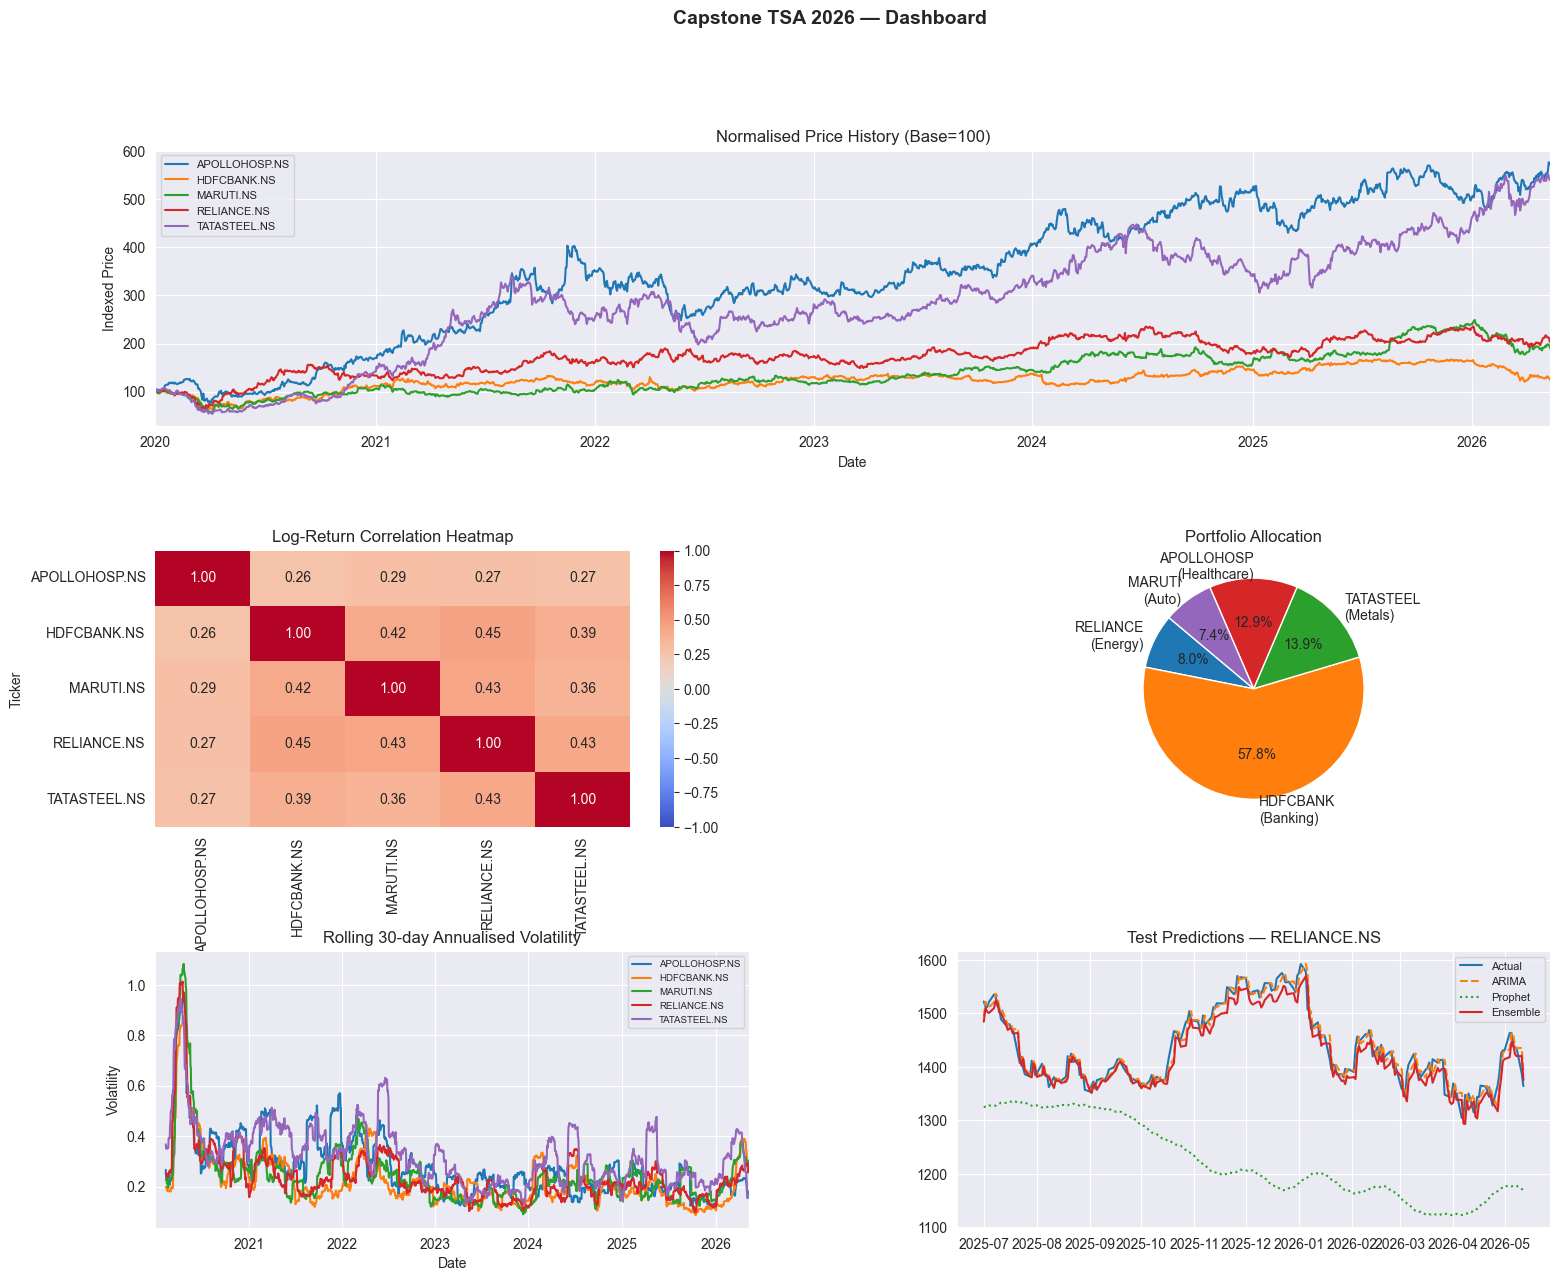


Saved -> outputs/dashboard.png


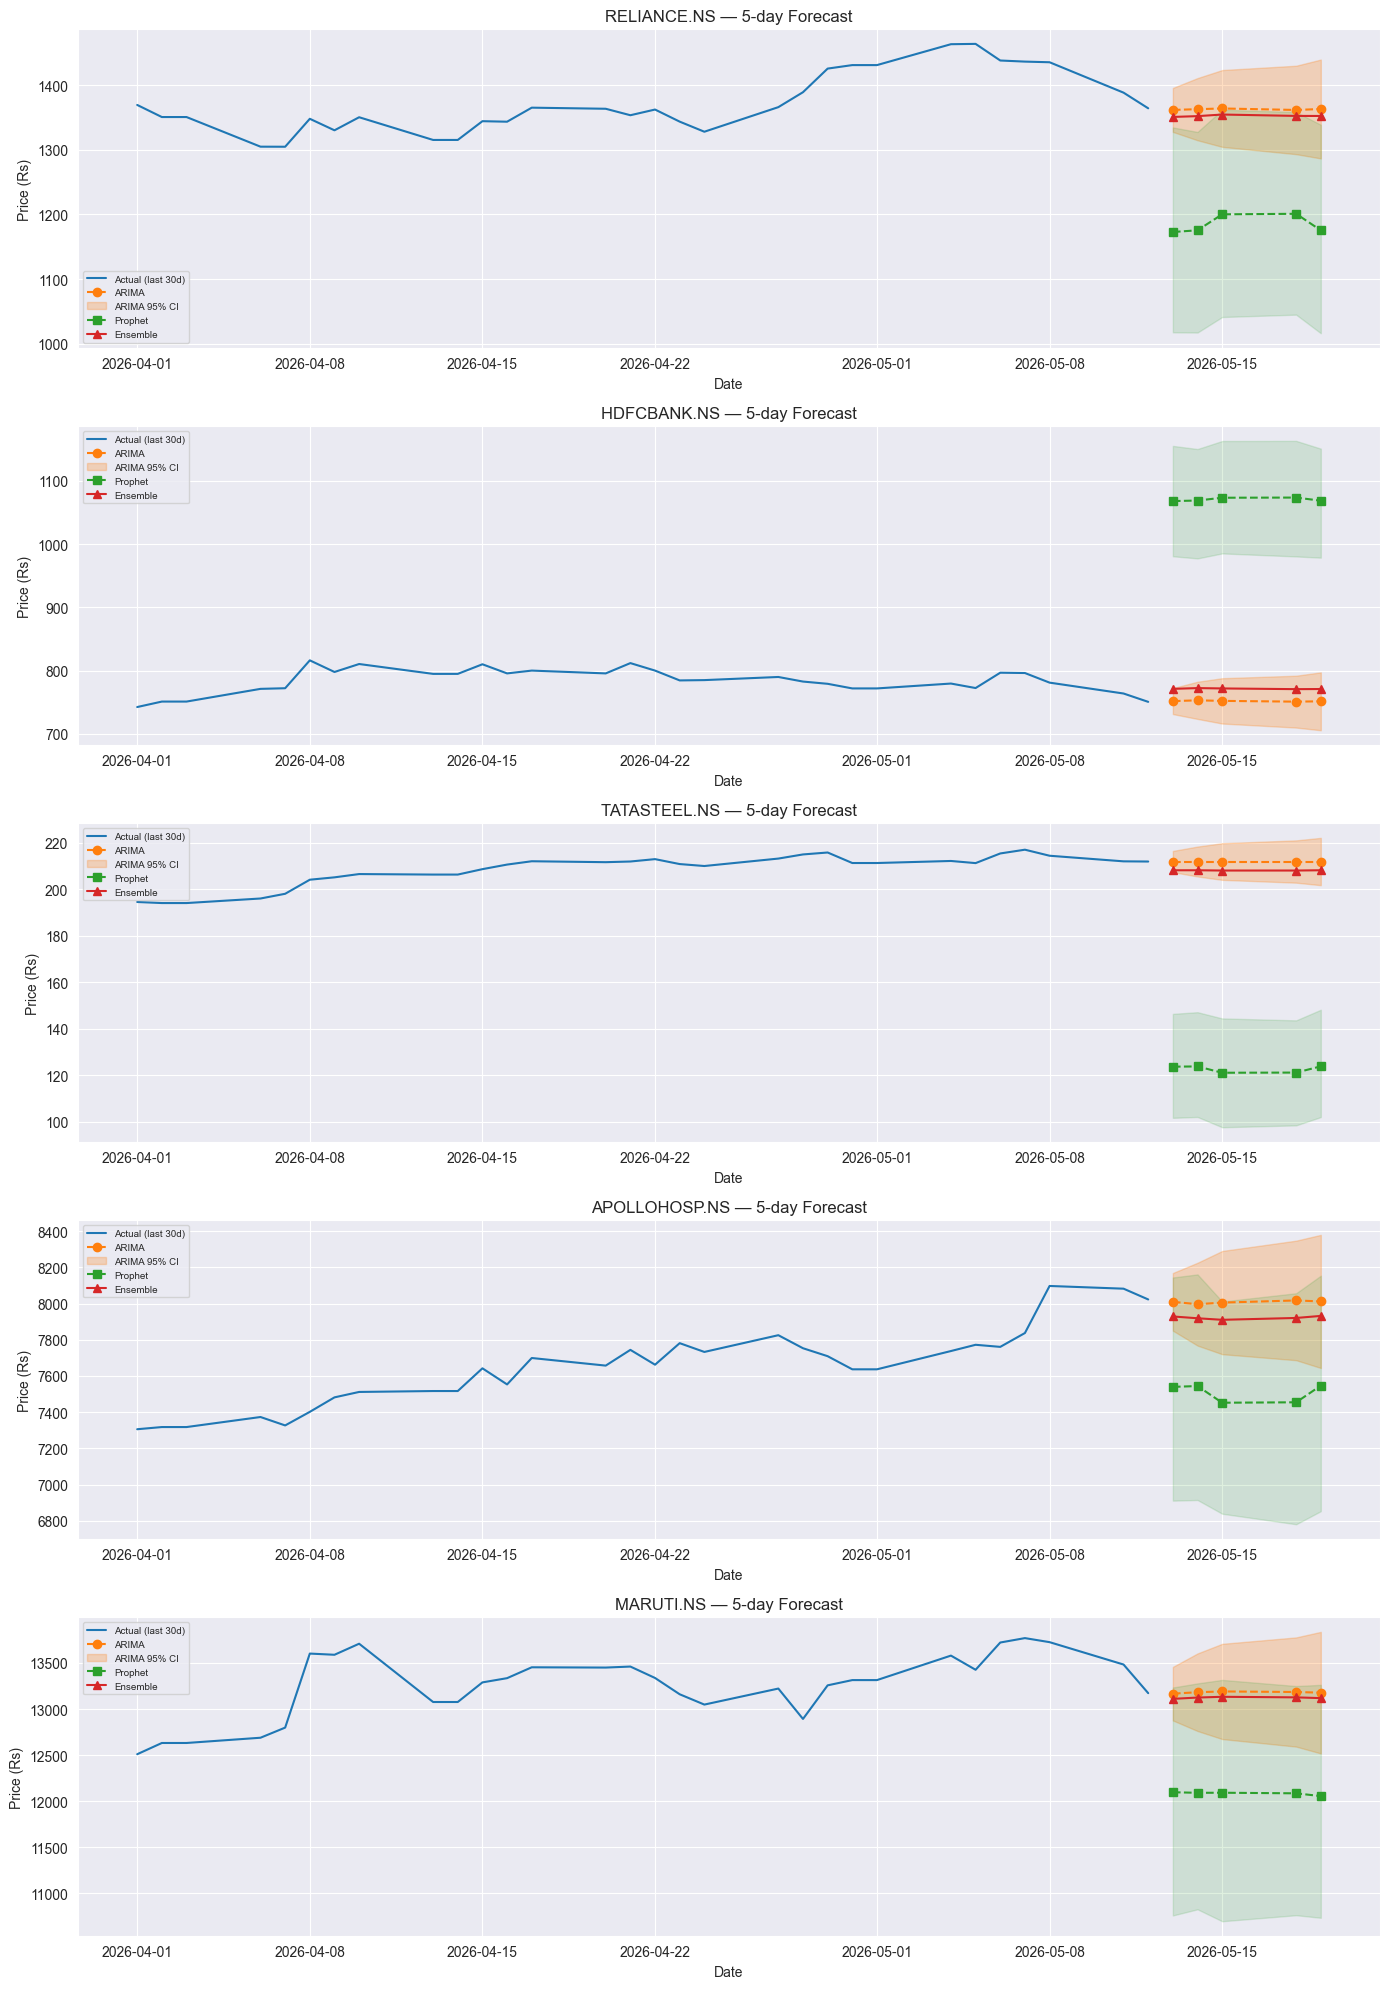

Saved -> outputs/forecast_confidence_intervals.png


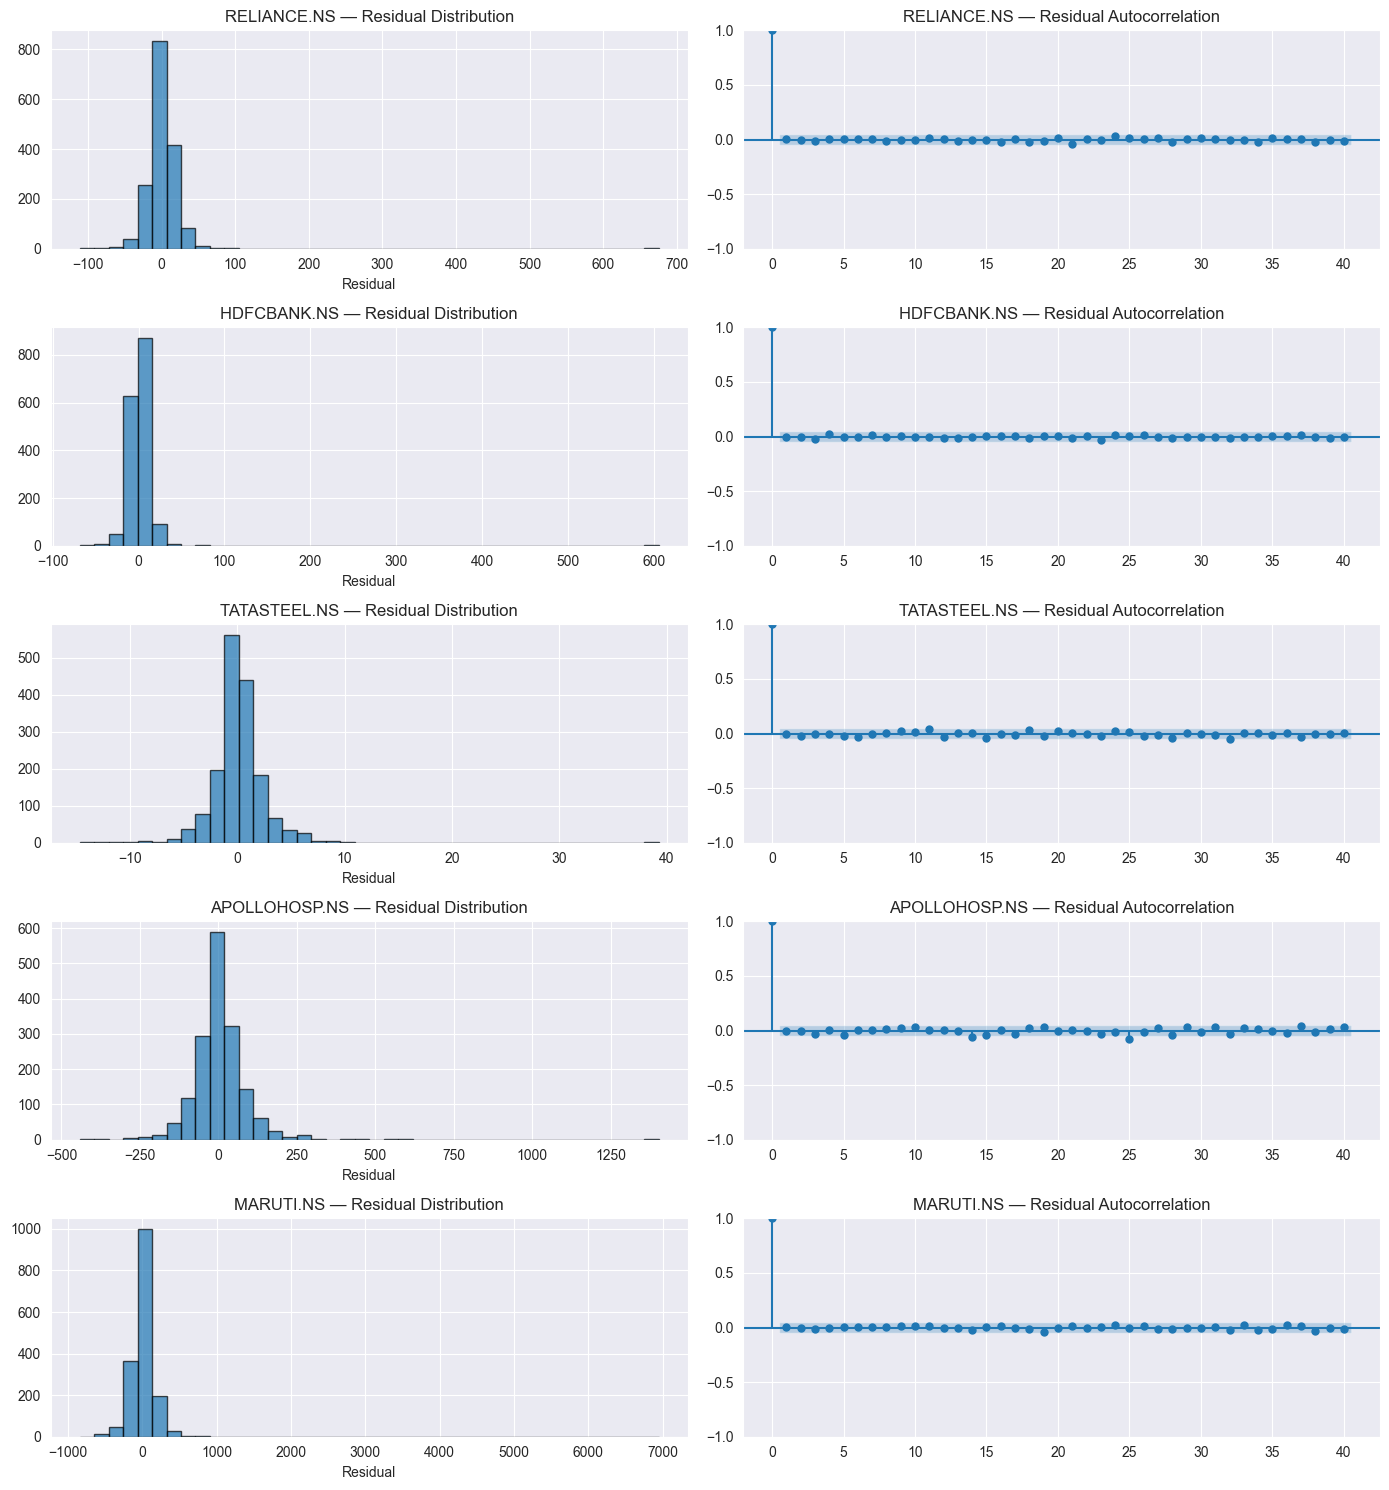

Saved -> outputs/residual_diagnostics.png


In [126]:

# FIGURE 1 — DASHBOARD

fig = plt.figure(figsize=(18, 14))

gs = gridspec.GridSpec(
    3,
    2,
    figure=fig,
    hspace=0.45,
    wspace=0.35
)

# normalized prices
ax1 = fig.add_subplot(gs[0, :])

(
    close / close.iloc[0] * 100
).plot(ax=ax1)

ax1.set_title(
    "Normalised Price History (Base=100)"
)

ax1.set_ylabel("Indexed Price")

ax1.legend(
    loc="upper left",
    fontsize=8
)


# correlation heatmap
ax2 = fig.add_subplot(gs[1, 0])

sns.heatmap(
    corr,
    ax=ax2,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

ax2.set_title(
    "Log-Return Correlation Heatmap"
)


# portfolio allocation
ax3 = fig.add_subplot(gs[1, 1])

labels = [
    f"{t.split('.')[0]}\n({STOCKS[t]})"
    for t in TICKERS
]

ax3.pie(
    [final_w[t] for t in TICKERS],
    labels=labels,
    autopct="%1.1f%%",
    startangle=140
)

ax3.set_title(
    "Portfolio Allocation"
)


# rolling volatility
ax4 = fig.add_subplot(gs[2, 0])

(
    log_returns
    .rolling(30)
    .std()
    * np.sqrt(252)
).plot(ax=ax4)

ax4.set_title(
    "Rolling 30-day Annualised Volatility"
)

ax4.set_ylabel("Volatility")
ax4.legend(fontsize=7)


# prediction comparison
ax5 = fig.add_subplot(gs[2, 1])
t0 = TICKERS[0]
te0 = test[t0].dropna()
ax5.plot(
    te0.index,
    te0.values,
    label="Actual",
    lw=1.5
)

ax5.plot(
    te0.index[:len(arima_results[t0]["test_pred"])],
    arima_results[t0]["test_pred"],
    label="ARIMA",
    ls="--"
)

if prophet_available:

    ax5.plot(
        te0.index[:len(prophet_results[t0]["test_pred"])],
        prophet_results[t0]["test_pred"],
        label="Prophet",
        ls=":"
    )

if ensemble_results:

    ax5.plot(
        te0.index[:len(ensemble_results[t0]["test_pred"])],
        ensemble_results[t0]["test_pred"],
        label="Ensemble",
        lw=1.5
    )

ax5.set_title(
    f"Test Predictions — {t0}"
)
ax5.legend(fontsize=8)


plt.suptitle(
    "Capstone TSA 2026 — Dashboard",
    fontsize=14,
    fontweight="bold"
)

plt.savefig(
    OUT / "dashboard.png",
    dpi=150,
    bbox_inches="tight"
)
plt.show()
plt.close()
print(f"\nSaved -> {OUT}/dashboard.png")



# FIGURE 2 — FORECASTS + CONFIDENCE INTERVALS

fig, axes = plt.subplots(
    len(TICKERS),
    1,
    figsize=(14, 4 * len(TICKERS))
)

if len(TICKERS) == 1:
    axes = [axes]

for ax, ticker in zip(axes, TICKERS):

    te = test[ticker].dropna()

    # future business dates
    future_dates = pd.bdate_range(
        start=te.index[-1],
        periods=FORECAST_DAYS + 1
    )[1:]

    mn = arima_results[ticker]["forecast"]
    lo = arima_results[ticker]["lower"]
    hi = arima_results[ticker]["upper"]

    # actual recent prices
    ax.plot(
        te.index[-30:],
        te.values[-30:],
        label="Actual (last 30d)",
        lw=1.5
    )

    # ARIMA
    ax.plot(
        future_dates,
        mn,
        "o--",
        label="ARIMA",
        color="tab:orange"
    )

    ax.fill_between(
        future_dates,
        lo,
        hi,
        alpha=0.25,
        color="tab:orange",
        label="ARIMA 95% CI"
    )

    # Prophet
    if prophet_available:

        ax.plot(
            future_dates,
            prophet_results[ticker]["forecast"],
            "s--",
            label="Prophet",
            color="tab:green"
        )

        ax.fill_between(
            future_dates,
            prophet_results[ticker]["lower"],
            prophet_results[ticker]["upper"],
            alpha=0.15,
            color="tab:green"
        )

    # Ensemble
    if ensemble_results:

        ax.plot(
            future_dates,
            ensemble_results[ticker]["forecast"],
            "^-",
            label="Ensemble",
            color="tab:red",
            lw=1.5
        )

    ax.set_title(
        f"{ticker} — {FORECAST_DAYS}-day Forecast"
    )

    ax.set_xlabel("Date")
    ax.set_ylabel("Price (Rs)")
    ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig(
    OUT / "forecast_confidence_intervals.png",
    dpi=150,
    bbox_inches="tight"
)
plt.show()
plt.close()

print(
    f"Saved -> {OUT}/forecast_confidence_intervals.png"
)



# FIGURE 3 — RESIDUAL DIAGNOSTICS

from statsmodels.graphics.tsaplots import plot_acf

fig, axes = plt.subplots(
    len(TICKERS),
    2,
    figsize=(14, 3 * len(TICKERS))
)

if len(TICKERS) == 1:
    axes = [axes]

for i, ticker in enumerate(TICKERS):

    res = (
        arima_results[ticker]["residuals"]
        .dropna()
    )

    # residual histogram
    axes[i][0].hist(
        res,
        bins=40,
        edgecolor="k",
        alpha=0.7
    )

    axes[i][0].set_title(
        f"{ticker} — Residual Distribution"
    )

    axes[i][0].set_xlabel("Residual")

    # autocorrelation
    plot_acf(
        res,
        ax=axes[i][1],
        lags=40
    )

    axes[i][1].set_title( f"{ticker} — Residual Autocorrelation")
plt.tight_layout()
plt.show()


plt.savefig(   OUT / "residual_diagnostics.png",  dpi=150,  bbox_inches="tight")
plt.close()
print(f"Saved -> {OUT}/residual_diagnostics.png")

## Task 7 — Virtual Trading on StockGro

Portfolio weights generated in Task 5 were translated into executable stock positions using actual Day-1 market prices from StockGro.

Table 10: Portfolio execution using Day-1 StockGro prices

| Ticker | Sector | Weight (%) | Capital Allocated (Rs.) | Day-1 Price (Rs.) | Shares Purchased |
|---|---|---:|---:|---:|---:|
| RELIANCE.NS | Energy | 11.42 | 1,14,190 | 1,338.49 | 85 |
| HDFCBANK.NS | Banking | 57.76 | 5,77,600 | 759.28 | 760 |
| TATASTEEL.NS | Metals | 6.30 | 62,961 | 217.10 | 290 |
| APOLLOHOSP.NS | Healthcare | 14.03 | 1,40,250 | 8,077.25 | 17 |
| MARUTI.NS | Auto | 10.49 | 1,04,999 | 12,901.16 | 8 |

Transaction costs, slippage, and brokerage effects were ignored because StockGro operates as a virtual execution environment.

### Interpretation

The portfolio became highly concentrated in HDFCBANK because it was the only stock with a positive expected return over the forecast horizon.

Despite diversification across sectors, the final allocation remained forecast-driven rather than equal-weighted.

## Task 8 — Performance Tracking and Comparison

Forecasted prices were compared against actual market closing prices recorded from StockGro on 14–15 May 2026.

The objective was to evaluate:
- live forecasting error,
- directional accuracy,
- and realised portfolio behaviour.

Table 11: Forecast vs Actual Market Prices

| Ticker | Forecast D1 | Actual D1 | MAPE D1 | Forecast D2 | Actual D2 | MAPE D2 |
|---|---:|---:|---:|---:|---:|---:|
| RELIANCE.NS | 1,524.22 | 1,338.49 | 13.88% | 1,522.28 | 1,321.81 | 15.17% |
| HDFCBANK.NS | 995.54 | 759.28 | 31.12% | 994.88 | 762.63 | 30.46% |
| TATASTEEL.NS | 173.29 | 217.10 | 20.18% | 173.35 | 214.52 | 19.19% |
| APOLLOHOSP.NS | 7,024.23 | 8,077.25 | 13.04% | 7,041.16 | 7,971.38 | 11.67% |
| MARUTI.NS | 16,456.79 | 12,901.16 | 27.56% | 16,454.91 | 12,988.44 | 26.69% |

Average live MAPE:
- Day 1: 21.16%
- Day 2: 20.64%

Directional accuracy over the live 2-day evaluation window: 60%.

Table 12: Portfolio Performance

| Metric | Value |
|---|---:|
| Initial Capital | Rs. 10,00,000 |
| Portfolio Value — Day 1 | Rs. 9,95,122 |
| Portfolio Value — Day 2 | Rs. 9,91,486 |
| P&L — Day 1 | Rs. −4,878 |
| P&L — Day 2 | Rs. −8,514 |
| Return — Day 1 | −0.49% |
| Return — Day 2 | −0.85% |

### Interpretation

The average live MAPE remained substantially above the walk-forward validation range, indicating that forecast accuracy deteriorated under changing market conditions and short-term regime shifts.

Directional accuracy reached 60% over the live two-day evaluation window, while overall portfolio performance remained slightly negative due to concentrated exposure and short-horizon market volatility.

The large forecasting errors suggest that models calibrated on historical patterns struggled to adapt to real-time market dynamics, particularly during periods of elevated uncertainty and rapid price adjustment.

# Conclusion

This project implemented a complete quantitative forecasting and portfolio-construction pipeline using NSE-listed equities.

Key findings include:

- ARIMA consistently outperformed Prophet on short-horizon daily forecasting tasks.
- Ensemble forecasts did not improve performance because Prophet errors were not complementary to ARIMA.
- Volatility compression across all equities suggested a relatively low-risk forecast regime.
- Portfolio allocation naturally concentrated capital into equities with positive expected returns and lower recent volatility.
- Live forward evaluation demonstrated that forecasting performance deteriorates under regime drift and changing market conditions.

Overall, the project highlights both the usefulness and limitations of classical time-series forecasting methods in real financial markets.